# EDA, limpieza y análisis de datos geográficos y demográficos

En este notebook realizaremos un Análisis Exploratorio de Datos (EDA) sobre el dataset que utilizaremos `Latitud - Longitud Chile.csv`, el cual contiene información geográfica y demográfica de las comunas de Chile. Posteriormente, llevaremos a cavo un proceso de limpieza y transformación de los datos para facilitar análisis.

Finalmente, utilizaremos la información procesada para construir un mapa interactivo que permita simular un incedio forestal en la Región del Biobío y estimar tanto la población potencialmente afectada como la cantidad de comunas impactadas por el evento.

### Objetivos
* Explorar y describir las características principales del dataset
* Limpiar y transformar los tipos de datos (tipo de datos, formato y selección de variables relevantes)
* Construir un mapa interactivo que permita relacionar la información geográfica y demográfica con el problema de estudio.

### Fuente
Los datos fueron obtenidos del repositorio https://github.com/altazor-1967/Comunas-de-Chile. 

### Diccionario de variables
| Columna                        | Descripción | 
|----------|-------------|
| CUT (Código Único Territorial) | Código único asociado a cada comuna  |
| Comuna                         | Nombre de la comuna |
| Provincia                      | Provincia a la que pertenece la comuna |
| Región                         | Región administrativa a la que pertenece la comuna |
| Superficie (km2)               | Superficie de la comuna expresada en kilómetros cuadrados  |
| Población Año 2017             | Población de la comuna según el Censo 2017 |
| Densidad (hab./km2)            | Densidad poblacional expresada en habitantes por kilómetro cuadrado |
| IDH 2005                       | Índice de Desarrollo Humano de la comuna para el año 2005  |
| Latitud (Decimal)              | Latitud del centro de la comuna en coordenadas decimales |
| Longitud (decimal)             | Longitud del centro de la comuna en coordenadas decimales |
| Latitud (Sexagesimal)	         | Latitud del centro de la comuna en coordenadas sexagecimales |
| Longitud (Sexagesimal)         | Longitud del centro de la comuna en coordenadas sexagecimales |

## 1. Configuración e inicialización

In [1]:
# Librerias
# Manipulación de datos
import pandas as pd
import numpy as np
import re

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns
from ipyleaflet import Map, Marker, Circle, basemaps, WidgetControl
import ipywidgets as widgets
from IPython.display import display
import folium

# Utilidades
from pathlib import Path

In [2]:
# Path al archivo
NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parent

DATA_DIR = PROJECT_ROOT / "data"

# Cargamos el dataset
raw_df = pd.read_csv(DATA_DIR / 'Latitud - Longitud Chile.csv')

raw_df.head(2)

,CUT (Código Único Territorial),Comuna,Provincia,Región,Superficie (km2),Población Año 2017,Densidad (hab./km2),IDH 2005,Latitud (Decimal),Longitud (decimal),Latitud (Sexagesimal),Longitud (Sexagesimal)
0,1101,Iquique,Iquique,Tarapacá,"2,242.10","191,468",85.4,0.766,-20.2439,-70.1389,-20°14' 38'',-70°8' 20''
1,1107,Alto Hospicio,Iquique,Tarapacá,572.90,"108,375",189.2,NaN,-20.2569,-70.0219,-20°15' 25'',-70°1' 19''


## 2. Análisis exploratorio de datos (EDA)

Aqui empezamos el análisis exploratorio (EDA) de los datos.

### 2.1 Vista preliminar

In [3]:
# Header del dataset
df = raw_df
df.head()

,CUT (Código Único Territorial),Comuna,Provincia,Región,Superficie (km2),Población Año 2017,Densidad (hab./km2),IDH 2005,Latitud (Decimal),Longitud (decimal),Latitud (Sexagesimal),Longitud (Sexagesimal)
0,1101,Iquique,Iquique,Tarapacá,"2,242.10","191,468",85.4,0.766,-20.2439,-70.1389,-20°14' 38'',-70°8' 20''
1,1107,Alto Hospicio,Iquique,Tarapacá,572.90,"108,375",189.2,NaN,-20.2569,-70.0219,-20°15' 25'',-70°1' 19''
2,1401,Pozo Almonte,Tamarugal,Tarapacá,"13,765.80","15,711",1.14,0.722,-20.2908,-69.6958,-20°17' 27'',-69°41' 45''
3,1402,Camiña,Tamarugal,Tarapacá,"2,200.20","1,250",0.57,0.619,-20.4828,-69.3669,-20°28' 58'',-69°22' 1''
4,1403,Colchane,Tamarugal,Tarapacá,"4,015.60","1,728",0.43,0.603,-19.2839,-68.6750,-19°17' 2'',"-68°40' 30"""


### 2.2 Estructura de los datos

In [4]:
# Información sobre el dataset
print(df.shape)
df.info()

(346, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 346 entries, 0 to 345
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   CUT (Código Único Territorial)  346 non-null    int64  
 1   Comuna                          346 non-null    object 
 2   Provincia                       346 non-null    object 
 3   Región                          346 non-null    object 
 4    Superficie (km2)               346 non-null    object 
 5   Población Año 2017              346 non-null    object 
 6   Densidad (hab./km2)             346 non-null    object 
 7   IDH 2005                        341 non-null    float64
 8   Latitud (Decimal)               346 non-null    float64
 9   Longitud (decimal)              346 non-null    float64
 10  Latitud (Sexagesimal)           346 non-null    object 
 11  Longitud (Sexagesimal)          346 non-null    object 
dtypes: float64(3), int64(1), o

#### Inspeccción inicial

Al revisar la estructura del dataset, observamos lo siguiente:

- El dataset tiene 346 filas, correspondientes a la totalidad de las comunas de Chile [[Chile.Gob (visto el 19/06/2026)](https://www.chile.gob.cl/chile/sobre-chile/asi-es-chile/organizacion-territorial/organizacion-territorial)]. Además tiene 12 columnas.
- Las columnas `Superficie (km2)`, `Población Año 2017` y `Densidad (hab./km2)` son cargadas como texto (`object`) en lugar de valores numéricos.
- Los nombres de las columnas tiene espacios innecesarios que difuciltan su manipulación.
- La columna `IDH2005` contiene valores nulos.
- Es posible estandarizar los nombres de la columnas para facilitar su lectura y uso durante el análisis.


Estos hallazgos justifican la realización de una etapa de limpieza y transformación de los datos antes de continuar con el análisis exploratorio.

## 3. Limpieza

### 3.1 Eliminar columnas innecesarias

In [5]:
# Eliminamos columnas que no vamos a usar
df = df.drop(columns=['CUT (Código Único Territorial)', 'IDH 2005', 'Latitud (Sexagesimal)', 'Longitud (Sexagesimal)'])

### 3.2 Limpiar y simplificar nombres de columnas

In [6]:
# Funcion para trasformar todo en minúsculas, quitar espacios sobrantes,
# limpiar tildes, eliminar caracteres especiales como () y si hay espacios entre
# palabras reemplazalos por _
def limpiar_columna(col):
    col = col.strip().lower()
    col = re.sub(r'[áéíóú]', lambda m: 'aeiou'['áéíóú'.index(m.group())], col)
    col = re.sub(r'[^\w\s]', '', col)
    col = re.sub(r'\s+', '_', col)
    return col

df.columns = [limpiar_columna(c) for c in df.columns] # Aplicamos la funcion

df = df.rename(columns={
    'cut_codigo_unico_territorial': 'cut',  # Simplificamos nombres
    'poblacion_año_2017': 'poblacion_2017'
})

df.columns

Index(['comuna', 'provincia', 'region', 'superficie_km2', 'poblacion_2017',
       'densidad_habkm2', 'latitud_decimal', 'longitud_decimal'],
      dtype='object')

### 3.4 Eliminar espacios y caracteres especiales de los valores de las columnas texto

In [7]:
# Estudiamos los valores strings de algunas columnas y ver si tienen caracteres especiales
columnas = ['comuna', 'provincia', 'region', 'superficie_km2', 'poblacion_2017', 'densidad_habkm2']

for col in columnas:
    print(f"\n{col}:")
    print(df[col].head(10).tolist())


comuna:
['Iquique', 'Alto Hospicio', 'Pozo Almonte', 'Camiña', 'Colchane', 'Huara', 'Pica', 'Antofagasta', 'Mejillones', 'Sierra Gorda']

provincia:
['Iquique', 'Iquique', 'Tamarugal', 'Tamarugal', 'Tamarugal', 'Tamarugal', 'Tamarugal', 'Antofagasta', 'Antofagasta', 'Antofagasta']

region:
['\xa0Tarapacá', '\xa0Tarapacá', '\xa0Tarapacá', '\xa0Tarapacá', '\xa0Tarapacá', '\xa0Tarapacá', '\xa0Tarapacá', '\xa0Antofagasta', '\xa0Antofagasta', '\xa0Antofagasta']

superficie_km2:
[' 2,242.10 ', ' 572.90 ', ' 13,765.80 ', ' 2,200.20 ', ' 4,015.60 ', ' 10,474.60 ', ' 8,934.30 ', ' 30,718.10 ', ' 3,803.90 ', ' 12,886.00 ']

poblacion_2017:
[' 191,468 ', ' 108,375 ', ' 15,711 ', ' 1,250 ', ' 1,728 ', ' 2,730 ', ' 9,296 ', ' 361,873 ', ' 13,467 ', ' 10,186 ']

densidad_habkm2:
['85.4', '189.2', '1.14', '0.57', '0.43', '0.26', '1.04', '11.8', '3.54', '0.79']


#### Hallazgo

* Se identificó la presencia del caracter especial `\xa0` en algunos valores de la columna `region`.
* Las columnas `superficie_km2` y `poblacion_2017` tienen espacios innecesarios en sus valores que dificultan su converción a números.
* Las columnas `region`, `provincia` y `comuna`, contienen información facilmente legible, por lo que las mantendremos como estan para facilitar la futura visualización.

Estos hallazgos justifican la limpieza de caracteres especiales y espacios innecesarios antes de realizar las transformaciones de tipo de datos.


In [8]:
# Limpiamos el valores extra de region
df['region'] = df['region'].str.replace('\xa0', '', regex=False).str.strip()

df['region'].unique()

array(['Tarapacá', 'Antofagasta', 'Atacama', 'Coquimbo', 'Valparaíso',
       "Lib. Gral. Bernardo O' Higgins", 'Maule', 'Biobío',
       'La Araucanía', 'Los Lagos', 'Aysén del Gral. C. Ibáñez del Campo',
       'Magallanes y Antártica Chilena', 'Metropolitana de Santiago',
       'Los Ríos', 'Arica y Parinacota', 'Ñuble'], dtype=object)

In [9]:
# Reemplazar los valores object por floats, elminando tambien las comas que se usan
# que se usan para marcar los miles
for col in ['superficie_km2', 'poblacion_2017', 'densidad_habkm2']:
    if df[col].dtype == 'object' or df[col].dtype == 'str':  # solo si todavía es texto
         df[col] = (df[col]
               .str.strip()
               .str.replace(',', '')
               .str.replace('\xa0', '')   # espacio especial, por si acaso
               .str.replace(' ', '')      # espacio normal, por si acaso
               .astype(float))

df.dtypes.to_frame().T

,comuna,provincia,region,superficie_km2,poblacion_2017,densidad_habkm2,latitud_decimal,longitud_decimal
0,object,object,object,float64,float64,float64,float64,float64


### 3.5 Subgrupo de datos con solo la Región del Biobío

In [10]:
# Seleccionamos la región
df_biobio = df[df["region"] == "Biobío"].copy() # Le avisamos a pandas que queremos un dataset nuevo

print(df_biobio.shape)
df_biobio.head()

(33, 8)


,comuna,provincia,region,superficie_km2,poblacion_2017,densidad_habkm2,latitud_decimal,longitud_decimal
141,Concepción,Concepción,Biobío,221.6,223574.0,1008.9,-36.8150,-73.0289
142,Coronel,Concepción,Biobío,279.4,116262.0,416.1,-36.9819,-73.1569
143,Chiguayante,Concepción,Biobío,71.5,85938.0,1201.9,-36.9089,-73.0278
144,Florida,Concepción,Biobío,608.6,10624.0,17.5,-36.8208,-72.6619
145,Hualqui,Concepción,Biobío,530.5,24333.0,589.2,-36.9669,-72.9328


### 3.6 Verificar ausencia de nulos y duplicados

In [11]:
# Verificar nulos y duplicados

nulos = df_biobio.isna().sum()
duplicados = df_biobio['comuna'].duplicated().sum()

print('Comunas duplicadas ' + str(duplicados))
print('Numero de nulos por columna')
nulos.to_frame().T

Comunas duplicadas 0
Numero de nulos por columna


,comuna,provincia,region,superficie_km2,poblacion_2017,densidad_habkm2,latitud_decimal,longitud_decimal
0,0,0,0,0,0,0,0,0


#### Verificación

Tras la limpieza
- Estandarizamos los nombres de las columnas.
- Las columnas `Superficie (km2)`, `Población Año 2017` y `Densidad (hab./km2)` son columnas numéricas.
- Utilizaremos un subset que se concentra en la región del Biobío.
- Este set no tiene nulos ni duplicados.

## Continuacion del análisis explorativo

### 2.3 Estadísticas descriptivas

In [12]:
resumen = df_biobio.describe()

cols_formato = ['poblacion_2017', 'superficie_km2', 'densidad_habkm2']
resumen[cols_formato] = resumen[cols_formato].map(lambda x: f'{x:,.2f}')

resumen

,superficie_km2,poblacion_2017,densidad_habkm2,latitud_decimal,longitud_decimal
count,33.00,33.00,33.00,33.000000,33.000000
mean,723.95,"47,175.91",282.00,-37.239039,-72.767288
std,575.64,"57,019.28",491.20,0.582693,0.555469
min,53.50,"3,412.00",2.16,-38.618900,-73.642800
25%,221.60,"10,624.00",16.70,-37.605800,-73.155000
50%,624.40,"25,522.00",36.90,-37.256900,-72.935300
75%,994.30,"47,367.00",320.60,-36.908900,-72.398900
max,"2,124.60","223,574.00","1,715.40",-35.282800,-71.324200


### 2.4 Ranking ciudades más y menos pobladas de la región

In [13]:
# Ranking poblacional region del Biobío
columnas = ['comuna', 'poblacion_2017', 'densidad_habkm2','superficie_km2']

top5 = df_biobio.nlargest(5, 'poblacion_2017')[columnas].reset_index(drop=True)
bottom5 = df_biobio.nsmallest(5, 'poblacion_2017')[columnas].reset_index(drop=True)

comparacion = pd.concat(
    [top5.rename(columns={
            "comuna": "Top 5 comunas",
            "poblacion_2017": "Población"}),bottom5.rename(columns={
            "comuna": "Bottom 5 comunas",
            "poblacion_2017": "Población"})],axis=1)

comparacion

,Top 5 comunas,Población,densidad_habkm2,superficie_km2,Bottom 5 comunas,Población,densidad_habkm2,superficie_km2
0,Concepción,223574.0,1008.9,221.6,San Rosendo,3412.0,36.90,92.4
1,Los Ángeles,202331.0,115.7,1748.2,Quilaco,3988.0,3.55,1123.7
2,Talcahuano,151749.0,1644.1,92.3,Antuco,4073.0,2.16,1884.1
3,San Pedro de La Paz,131808.0,1171.6,112.5,Alto Biobío,5923.0,2.79,2124.6
4,Coronel,116262.0,416.1,279.4,Contulmo,6031.0,9.44,638.8


#### Conclusiones

A partir de las estadísticas descriptivas, podemos observar:

- La desviación estándar de la superficie comunal presenta una variabilidad considerable. Aunque es inferior a su promedio, ambas magnitudes son comparables. No reulta llamativo, ya que las comunas de la Región del Biobío presentan tamaños muy heterogéneos. Los cuartiles observados refuerzan esta disperción en la distribución.

- Tanto la población como la densidad habitacional presentan desviaciones estándar superiores a sus respectivos promedios. Esto evidencia una alta variabilidad entre las comunas de la región. Por ejemplo, la comuna menos poblada, san Rosendo, cuenta con aproximadamente 3 mil habitantes, mientras que la más poblada, Concepción, supera los 220 mil habitantes. 

- Esta variabilidad también se observa al comparar población y superficie. Algunas de las comunas más pobladas de la región, como Concepción, Talcahuano y San Pedro de la Paz, poseen superficies inferiores a 250 kilómetros cuadrados. En contraste, comunas como Los Ángeles, Antuco y Alto Biobío superan los 1000 kilómetros cuadrados de superficie, pero no necesariamenete su población es proporcionalmente mayor.

- Los valores de latitud y longitud se encuentran dentro de los esperados para la región, lo que valida en primera instancia la consistencia geográfica de los datos. [SINCA (visto el 19/06/2026)](https://sinca.mma.gob.cl/index.php/region/info/id/VIII).

### 2.5 Histograma Poblacional, Densidad habitacional y Superficie

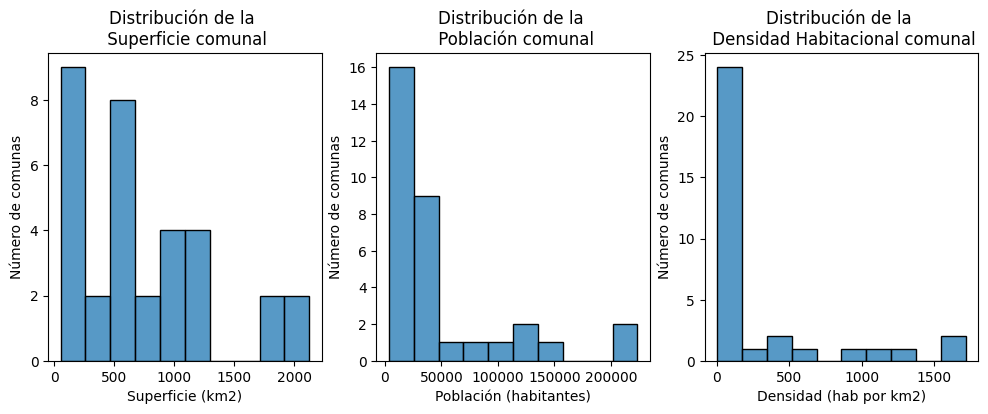

In [14]:
f, axs = plt.subplots(1, 3, figsize=(12, 4))

sns.histplot(data=df_biobio, x='superficie_km2', bins=10, ax=axs[0])

axs[0].set_title('Distribución de la \n Superficie comunal')
axs[0].set_xlabel('Superficie (km2)')
axs[0].set_ylabel('Número de comunas')

sns.histplot(data=df_biobio, x='poblacion_2017', bins=10, ax=axs[1])

axs[1].set_title('Distribución de la \n Población comunal')
axs[1].set_xlabel('Población (habitantes)')
axs[1].set_ylabel('Número de comunas')

sns.histplot(data=df_biobio, x='densidad_habkm2', bins=10, ax=axs[2])

axs[2].set_title('Distribución de la \n Densidad Habitacional comunal')
axs[2].set_xlabel('Densidad (hab por km2)')
axs[2].set_ylabel('Número de comunas')



plt.show()

### 2.6 Mapa de la región con centros geográficos comunales

In [15]:
# si no corre, en la terminar usa jupyter trust .\01_geografia_y_poblacion.ipynb o arriba del kernel cambiar de not trsuted a trusted

mapa = folium.Map(
    location=[-37.24, -72.77],
    zoom_start=8,
    width=700,
    height=500
)

for _, row in df_biobio.iterrows():
    folium.CircleMarker(
        location=[row["latitud_decimal"], row["longitud_decimal"]],
        radius=4,
        popup=row["comuna"],
        fill=True
    ).add_to(mapa)

mapa

### Problema de la población concentrada en un punto

En la siguiente sección implementaremos un simulador de incendios forestales que permitirá estimar las comunas y la población potencialmente afectada a partir de un punto de origen y un radio de propagación.

Sin embargo, al analizar la estructura del dataset identificamos una limitación importante:

- Cada comuna se encuentra representada por un único punto geográfico, correspondiente a su centro aproximado.
- Como consecuencia, toda la población de una comuna queda asociada a dicho punto.
- Bajo este supuesto, una comuna solo sería considerada afectada cuando el centro comunal se encuentre dentro del área del incendio.
- Además, una vez alcanzado dicho punto, toda la población de la comuna sería contabilizada como afectada de manera inmediata, independientemente de qué proporción de su territorio haya sido realmente alcanzada por el incendio.

Este comportamiento no representa adecuadamente la distribución espacial de la población dentro de una comuna. Por ello, proponemos una aproximación que permita estimar de forma más realista la población potencialmente afectada.

**Aproximación mediante intersección de círculos**

Para cada comuna construiremos una representación simplificada de su territorio mediante un círculo cuyo centro coincida con las coordenadas registradas en el dataset y cuya superficie sea equivalente a la superficie real de la comuna. 

De forma análoga, el incendio será representado mediante un círculo definido por un punto de origen y un radio de propagación.

La proporción de territorio comunal afectado se estimará a partir del área de intersección entre ambos círculos. Asumiendo una distribución homogénea de la población dentro de cada comuna, dicha proporción podrá utilizarse para estimar la población potencialmente afectada:

Población comunal * Área intersectada/Área de la comuna

Esta aproximación no busca reproducir con exactitud la forma real de las comunas, sino proporcionar una estimación más realista que la representación puntual original.

Para implementar esta aproximación, añadiremos al dataset una variable adicional correspondiente al radio equivalente de cada comuna, calculado a partir de su superficie.

In [16]:
df_biobio['radio_comuna_km'] = np.sqrt(df_biobio['superficie_km2'] / np.pi)
df_biobio.head()

,comuna,provincia,region,superficie_km2,poblacion_2017,densidad_habkm2,latitud_decimal,longitud_decimal,radio_comuna_km
141,Concepción,Concepción,Biobío,221.6,223574.0,1008.9,-36.8150,-73.0289,8.398659
142,Coronel,Concepción,Biobío,279.4,116262.0,416.1,-36.9819,-73.1569,9.430577
143,Chiguayante,Concepción,Biobío,71.5,85938.0,1201.9,-36.9089,-73.0278,4.770656
144,Florida,Concepción,Biobío,608.6,10624.0,17.5,-36.8208,-72.6619,13.918455
145,Hualqui,Concepción,Biobío,530.5,24333.0,589.2,-36.9669,-72.9328,12.994745


### Guardando el dataset limpio

In [ ]:
# Guardando el csv limpio con las columnas que sabemos que queremos

df_biobio = df_biobio[['comuna', 'provincia', 'region', 'superficie_km2', 'poblacion_2017','densidad_habkm2', 'latitud_decimal', 'longitud_decimal','radio_comuna_km']]

df_biobio.to_csv(DATA_DIR / 'biobio_limpio.csv', index=False)


## 4. Mapa interactivo

El objetivo de esta sección es construir una herramienta interactiva que permita simular un incendio forestal en la Región del Biobío. A partir de un punto de origen y un radio de propagación, el sistema estimará las comunas y la población potencialmente afectada utilizando información geográfica y demográfica real.

### 4.1 Calculo de la distancia

Para determinar qué comunas podrían verse afectadas por un incendio es necesario calcular la distancia entre el foco del incendio y el centro geográfico de cada comuna.

Dado que la Tierra posee una superficie curva, utilizar geometría cartesiana plana (por ejemplo, la distancia euclidiana entre dos puntos) introduciría errores crecientes a medida que aumentan las distancias consideradas. Para evitar este problema utilizaremos la fórmula del semiverseno (Haversine), ampliamente utilizada en aplicaciones geográficas para calcular la distancia más corta entre dos puntos sobre la superficie terrestre a partir de sus coordenadas de latitud y longitud.

Si bien esta fórmula asume una Tierra perfectamente esférica, la diferencia respecto a modelos más complejos es generalmente inferior al 0,5 %, lo que resulta suficientemente preciso para la escala espacial considerada en este proyecto.

In [18]:
def calcular_distancia_haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


### 4.2 Calculo de área interseccionada de dos circulos

In [19]:
# Calculo de la interseccion de dos circulos
def area_interseccion_circulos(d, r1, r2):
  # Caso 1: los círculos no se tocan
    if d >= r1 + r2:
        return 0

    # Caso 2: un círculo contiene completamente al otro
    if d <= abs(r1 - r2):
        return np.pi * min(r1, r2)**2

    # Caso 3: se superponen parcialmente (fórmula de la "lente")
    parte1 = r1**2 * np.arccos((d**2 + r1**2 - r2**2) / (2*d*r1))
    parte2 = r2**2 * np.arccos((d**2 + r2**2 - r1**2) / (2*d*r2))
    parte3 = 0.5 * np.sqrt((-d+r1+r2) * (d+r1-r2) * (d-r1+r2) * (d+r1+r2))

    return parte1 + parte2 - parte3

#### Sección aparte: validación del método

Para verificar la correcta implementación del cálculo del área de intersección entre círculos, se compararán los resultados obtenidos mediante la solución analítica con una aproximación numérica basada en simulación Monte Carlo. Si ambas metodologías producen resultados similares, se considerará validada la implementación analítica utilizada por el simulador.

In [20]:
print(area_interseccion_circulos(d=12, r1=10, r2=5))

17.009800104552426


In [21]:
np.random.seed(42)
def validar_montecarlo(d, r1, r2, n=100000):
    """Genera puntos en círculo r2 centrado en (d,0), cuenta cuántos caen dentro de círculo r1 centrado en origen"""
    angulos = np.random.uniform(0, 2*np.pi, n)
    radios = np.sqrt(np.random.uniform(0, r2**2, n))

    x = d + radios * np.cos(angulos)
    y = radios * np.sin(angulos)

    dentro = (x**2 + y**2) <= r1**2
    proporcion = dentro.mean()

    return proporcion * np.pi * r2**2

print(validar_montecarlo(d=12, r1=10, r2=5))
print('Diferencia del ' + str(1-validar_montecarlo(d=12, r1=10, r2=5)/area_interseccion_circulos(d=12, r1=10, r2=5)))

16.978737496326037
Diferencia del 0.0039039568467063024


Diferencia menor al 1%, la formula esta bien implementada.

### 4.3 Calculo del área interseccionada aplicada a un dataframe

In [22]:
def area_interseccion_vectorizada(d, r1, r2):
    """
    Versión vectorizada de area_interseccion_circulos.
    d, r1, r2 pueden ser arrays (ej. columnas de un DataFrame).
    """
    # Caso 1: no se tocan
    sin_contacto = d >= r1 + r2

    # Caso 2: uno contiene al otro
    contenido = d <= np.abs(r1 - r2)
    area_contenido = np.pi * np.minimum(r1, r2)**2

    # Caso 3: superposición parcial (fórmula general)
    # Evitamos división por cero usando un d mínimo donde no aplica
    d_seguro = np.where(d == 0, 1e-9, d)

    parte1 = r1**2 * np.arccos(np.clip((d_seguro**2 + r1**2 - r2**2) / (2*d_seguro*r1), -1, 1))
    parte2 = r2**2 * np.arccos(np.clip((d_seguro**2 + r2**2 - r1**2) / (2*d_seguro*r2), -1, 1))
    parte3 = 0.5 * np.sqrt(np.clip((-d_seguro+r1+r2)*(d_seguro+r1-r2)*(d_seguro-r1+r2)*(d_seguro+r1+r2), 0, None))

    area_parcial = parte1 + parte2 - parte3

    # Combina los 3 casos según corresponda en cada posición del array
    resultado = np.where(sin_contacto, 0, np.where(contenido, area_contenido, area_parcial))

    return resultado

### 4.4 Celda iniciadora de mapa

In [23]:
# Usamos otro basemap porque el origanal daba problemas con colab
mapa = Map(center=(-37.24, -72.77), zoom=8, basemap=basemaps.CartoDB.Positron)

indicador = widgets.HTML(value="<b>Haz clic en el mapa para simular un incendio</b>")

slider_radio = widgets.FloatSlider(
    value=5,
    min=1,
    max=50,
    step=1,
    description='Radio (km):',
    continuous_update=True  # actualiza mientras arrastras, no solo al soltar
)

origen = {'lat': None, 'lng': None}
marcador_actual = None
circulo_actual = None

def actualizar_simulacion():
    global marcador_actual, circulo_actual

    if origen['lat'] is None:
        return  # todavía no se ha hecho clic en el mapa

    lat, lng = origen['lat'], origen['lng']
    radio_km = slider_radio.value

    # quitar marcador/círculo anterior
    if marcador_actual:
        mapa.remove_layer(marcador_actual)
    if circulo_actual:
        mapa.remove_layer(circulo_actual)

    # redibujar con el radio actual del slider
    marcador_actual = Marker(location=(lat, lng))
    mapa.add_layer(marcador_actual)

    circulo_actual = Circle(location=(lat, lng), radius=int(radio_km * 1000), color='red', fill_color='red', fill_opacity=0.3)
    mapa.add_layer(circulo_actual)

    # recalcular población
    distancias = calcular_distancia_haversine(lat, lng, df_biobio['latitud_decimal'], df_biobio['longitud_decimal'])

    areas_interseccion = area_interseccion_vectorizada(distancias, radio_km, df_biobio['radio_comuna_km'])
    area_total_comuna = np.pi * df_biobio['radio_comuna_km']**2
    proporcion_afectada = areas_interseccion / area_total_comuna

    poblacion_afectada = (df_biobio['poblacion_2017'] * proporcion_afectada).sum()
    afectadas = df_biobio[proporcion_afectada > 0]  # cualquier superposición cuenta

    indicador.value = f"""
    <b>📍 Origen:</b> ({lat:.4f}, {lng:.4f})<br>
    <b>Radio:</b> {radio_km:.0f} km<br>
    <b>Comunas afectadas:</b> {len(afectadas)}<br>
    <b>Población estimada:</b> {poblacion_afectada:,.0f}
    """

def manejar_clic(**kwargs):
    if kwargs.get('type') != 'click':
        return  # ignorar eventos que no sean clics en el mapa
    lat, lng = kwargs['coordinates']
    origen['lat'], origen['lng'] = lat, lng
    actualizar_simulacion()


def manejar_slider(change):
    actualizar_simulacion()


mapa.on_interaction(manejar_clic)
slider_radio.observe(manejar_slider, names='value')


display(mapa, slider_radio, indicador)

Map(center=[-37.24, -72.77], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom…

FloatSlider(value=5.0, description='Radio (km):', max=50.0, min=1.0, step=1.0)

HTML(value='<b>Haz clic en el mapa para simular un incendio</b>')

### Limpiar metadata

In [24]:
import json

with open('01_geografia_y_poblacion.ipynb', 'r', encoding='utf-8') as f:
    nb = json.load(f)

# Elimina la metadata de widgets si existe
if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']

with open('01_geografia_y_poblacion.ipynb', 'w', encoding='utf-8') as f:
    json.dump(nb, f, indent=1, ensure_ascii=False)